In [16]:
import numpy as np
from IQAEBinom_FinalRoundRedo import IQAEBinom_FinalRoundRedo
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick
from matplotlib.ticker import ScalarFormatter 
import pickle
import datetime

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
ps = np.linspace(0.001, 0.999, 201)

In [ ]:
errAvgs = np.array([])
errStds = np.array([])
biasesMonte = np.array([])
for p in ps:
    print(p, datetime.datetime.now())
    results = np.array([])

    for i in range(nEstim):
        result = IQAEBinom_FinalRoundRedo(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
        results = np.append(results, result)

    resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAEFinalRoundRedo_pTrue" + str(p) + "_epsilon0001_alpha005_nShotUnit1.dat"
    with open(resFileName, 'wb') as f:
        pickle.dump(results, f) 
    errs = [r["Estimate"] - p for r in results]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))


In [ ]:
results[8]

{'Estimate': 0.9990506337363769,
 'TotalOracleCalls': 4108,
 'nGrover': [0, 1, 3, 7, 15, 15],
 'nShots': [87, 32, 22, 115, 33, 33],
 'n1s': [87, 32, 22, 82, 13, 11],
 'thetaIntervals': [[0, 1.5707963267948966],
  [1.0487221370417417, 1.5707963267948966],
  [1.346463220830884, 1.5707963267948966],
  [1.4660982195192294, 1.5707963267948966],
  [1.5201660074200063, 1.549363542802598],
  [1.5281597703416396, 1.5530659914173925],
  [1.5205261170814557, 1.5509368655101787]],
 'ampSqIntervals': [[0, 1],
  [0.7513191658460966, 1.0],
  [0.9505132265392121, 1.0],
  [0.9890783007483601, 1.0],
  [0.997438760401302, 0.99954070610453],
  [0.9981832253444953, 0.9996856681477614],
  [0.997475034032897, 0.999605653644735]]}

In [ ]:
errAvgs

array([-1.23324613e-05,  1.86435588e-06, -1.75592612e-06, -4.42552732e-06,
        2.58988781e-06,  7.06271874e-07, -2.35183929e-06, -6.71044267e-07,
        3.90126998e-06,  3.09515583e-06, -8.38893618e-07,  5.38382909e-07,
       -5.30322643e-06, -9.15192807e-06, -3.81385578e-06, -3.10783387e-06,
        4.00005749e-06, -5.42129528e-06,  3.18182107e-06, -4.04453274e-06,
        1.01556739e-06, -1.29504809e-06,  5.62413787e-06, -7.82003270e-06,
       -3.26208935e-06, -2.40195733e-06,  3.50966122e-06, -5.89952463e-06,
        1.00545546e-05,  7.31674570e-07,  2.65028037e-06,  5.74845659e-07,
       -1.60708420e-06, -2.15645546e-06, -2.50013746e-06, -1.67770825e-06,
        4.20597696e-06, -4.67020068e-06,  4.08059650e-06, -2.11172114e-06,
        1.54169846e-06, -7.06876948e-07,  2.01582674e-06,  7.57821012e-06,
       -8.86471314e-06, -3.88947202e-06,  5.48621393e-07, -8.85826395e-07,
       -3.48170705e-06,  2.15029986e-06,  4.71591822e-06, -4.12078426e-07,
       -3.09900216e-06,  

In [ ]:
errStds

array([0.00023577, 0.0002494 , 0.00025783, 0.00030532, 0.0002854 ,
       0.0002697 , 0.00031924, 0.00031123, 0.00030684, 0.00029286,
       0.00028597, 0.00028527, 0.00028562, 0.00030181, 0.00032505,
       0.00031606, 0.00032818, 0.00032326, 0.00033517, 0.00031311,
       0.00030977, 0.00031342, 0.0003097 , 0.00030878, 0.0002986 ,
       0.00029825, 0.00030254, 0.00030665, 0.00032526, 0.00026747,
       0.00032863, 0.0003225 , 0.00033417, 0.00031925, 0.00033218,
       0.00034725, 0.00032658, 0.00033836, 0.00033382, 0.00033697,
       0.00032852, 0.00033011, 0.00035405, 0.00033699, 0.00034043,
       0.00033039, 0.00032134, 0.0003176 , 0.0003237 , 0.00033214,
       0.00030137, 0.00034009, 0.00034289, 0.00034305, 0.00034061,
       0.00033151, 0.00034179, 0.00033688, 0.0003588 , 0.00035922,
       0.00034818, 0.00034544, 0.0003352 , 0.00035409, 0.00034692,
       0.00034517, 0.00032612, 0.00032016, 0.00034415, 0.00030834,
       0.00032246, 0.00032951, 0.00031118, 0.00031249, 0.00031

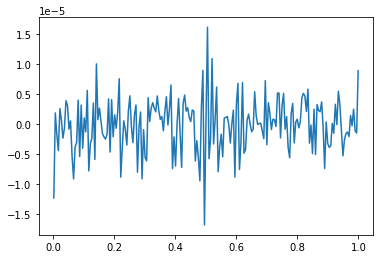

In [ ]:
ax = plt.gca()
plt.plot(ps, errAvgs)
plt.show()

In [4]:
import pandas as pd

In [5]:
errMeanDf = pd.DataFrame({"p":ps, "ErrMean":errAvgs, "ErrMeanAbs":np.abs(errAvgs), "ErrStd":errStds / np.sqrt(nEstim), "ErrMean/Std": np.abs(errAvgs) / (errStds / np.sqrt(nEstim))})
errMeanDf.sort_values("ErrMeanAbs", ascending=False)[:50]

NameError: name 'errAvgs' is not defined

In [ ]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230905_VariousP_FinalRedo/results_IQAEFinalRoundRedo_pTrue0.25049999999999994_epsilon0001_alpha005_nShotUnit1.dat", 'rb') as f:
    results02505 = pickle.load(f)

In [ ]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.25049999999999994_epsilon0001_alpha005.dat", 'rb') as f:
    results02505Before = pickle.load(f)

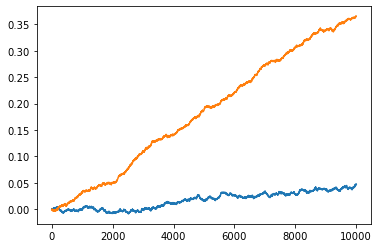

In [ ]:
errs = [r["Estimate"] - 0.2505 for r in results02505]
errsBefore = [r["Estimate"] - 0.2505 for r in results02505Before]
ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.plot(np.array(errsBefore).cumsum())
plt.show()

In [6]:
import os

dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230905_VariousP_FinalRedo"
files = os.listdir(dirPath)
print(files)

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

print(psInFiles)

['results_IQAEFinalRoundRedo_pTrue0.001_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.00599_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.01098_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.015969999999999998_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.02096_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.02595_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.03094_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.03593_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.04092_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.04591_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.0509_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.055889999999999995_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_

In [7]:
errAvgs = np.array([])
errStds = np.array([])

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    errs = [r["Estimate"] - p for r in res]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))

0.001
0.00599
0.01098
0.015969999999999998
0.02096
0.02595
0.03094
0.03593
0.04092
0.04591
0.0509
0.055889999999999995
0.06088
0.06587
0.07085999999999999
0.07585
0.08084
0.08582999999999999
0.09082
0.09580999999999999
0.1008
0.10579
0.11077999999999999
0.11577
0.12075999999999999
0.12574999999999997
0.13074
0.13573
0.14071999999999998
0.14570999999999998
0.1507
0.15569
0.16068
0.16566999999999998
0.17065999999999998
0.17565
0.18064
0.18563
0.19061999999999998
0.19560999999999998
0.2006
0.20559
0.21058
0.21556999999999998
0.22055999999999998
0.22554999999999997
0.23054
0.23553
0.24051999999999998
0.24550999999999998
0.25049999999999994
0.25549
0.26048
0.26547
0.27046
0.27545
0.28043999999999997
0.28542999999999996
0.29041999999999996
0.29541
0.3004
0.30539
0.31038
0.31537
0.32036
0.32535
0.33033999999999997
0.33532999999999996
0.34031999999999996
0.34530999999999995
0.3503
0.35529
0.36028
0.36527
0.37026
0.37525
0.38023999999999997
0.38522999999999996
0.39021999999999996
0.395209999999

In [8]:
errAvgsOrg = np.array([])
errStdsOrg = np.array([])
dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1"
#files = os.listdir(dirPath)
files = [f for f in os.listdir(dirPath) if os.path.isfile(os.path.join(dirPath, f))]

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    errs = [r["Estimate"] - p for r in res]
    errAvgsOrg = np.append(errAvgsOrg, np.mean(errs))
    errStdsOrg = np.append(errStdsOrg, np.std(errs))

0.001
0.00599
0.01098
0.015969999999999998
0.02096
0.02595
0.03094
0.03593
0.04092
0.04591
0.0509
0.055889999999999995
0.06088
0.06587
0.07085999999999999
0.07585
0.08084
0.08582999999999999
0.09082
0.09580999999999999
0.1008
0.10579
0.11077999999999999
0.11577
0.12075999999999999
0.12574999999999997
0.13074
0.13573
0.14071999999999998
0.14570999999999998
0.1507
0.15569
0.16068
0.16566999999999998
0.17065999999999998
0.17565
0.18064
0.18563
0.19061999999999998
0.19560999999999998
0.2006
0.20559
0.21058
0.21556999999999998
0.22055999999999998
0.22554999999999997
0.23054
0.23553
0.24051999999999998
0.24550999999999998
0.25049999999999994
0.25549
0.26048
0.26547
0.27046
0.27545
0.28043999999999997
0.28542999999999996
0.29041999999999996
0.29541
0.3004
0.30539
0.31038
0.31537
0.32036
0.32535
0.33033999999999997
0.33532999999999996
0.34031999999999996
0.34530999999999995
0.3503
0.35529
0.36028
0.36527
0.37026
0.37525
0.38023999999999997
0.38522999999999996
0.39021999999999996
0.395209999999

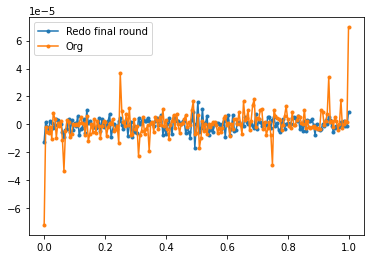

In [9]:
ax = plt.gca()
plt.plot(ps, errAvgs, label="Redo final round", marker=".")
plt.plot(ps, errAvgsOrg, label="Org", marker=".")
plt.legend()
plt.show()

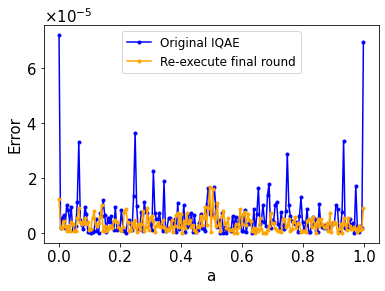

In [15]:
plt.rcParams["font.size"] = 15

ax = plt.gca()
plt.plot(ps, np.abs(errAvgsOrg), label="Original IQAE", marker=".", color="b")
plt.plot(ps, np.abs(errAvgs), label="Re-execute final round", marker=".", color="orange")

ax.set_xlabel("a")
ax.set_ylabel("Error")

ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(-5,-5)) 

plt.legend(fontsize=12)
plt.show()

In [12]:
avgBiasReduction = np.mean(np.abs(errAvgs) / np.abs(errAvgsOrg))
minBiasReduction = np.min(np.abs(errAvgs) / np.abs(errAvgsOrg))
print(avgBiasReduction)
print(minBiasReduction)

12.474516192449688
0.0060239287865933265


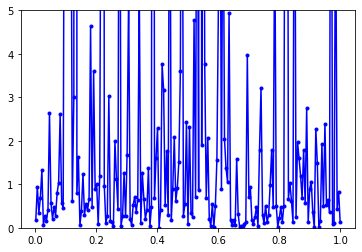

In [17]:
ax = plt.gca()
plt.plot(ps, np.abs(errAvgs) / np.abs(errAvgsOrg), marker=".", color="b")
ax.set_ylim([0,5])
plt.show()

In [38]:
biasReducDf = pd.DataFrame({"p":ps, "ErrRedo":np.abs(errAvgs), "ErrOrg":np.abs(errAvgsOrg), "Reduc":1 - np.abs(errAvgs) / np.abs(errAvgsOrg), "ErrStdOrg":errStdsOrg})
biasReducDfSort = biasReducDf.sort_values("Reduc", ascending=False)
biasReducDfSort["rank"] = np.arange(1, 202)
pd.set_option('display.max_rows', 201)
biasReducDfSort

,p,ErrRedo,ErrOrg,Reduc,ErrStdOrg,rank
81,0.40519,1.968917e-08,3.268494e-06,0.993976,0.000272,1
134,0.66966,7.958264e-08,1.029113e-05,0.992267,0.000269,2
183,0.91417,1.021530e-07,8.815112e-06,0.988412,0.000260,3
186,0.92914,8.819998e-08,7.524220e-06,0.988278,0.000246,4
117,0.58483,4.556324e-08,2.467747e-06,0.981537,0.000273,5
159,0.79441,3.315618e-07,1.298028e-05,0.974456,0.000275,6
135,0.67465,1.261506e-07,4.127416e-06,0.969436,0.000273,7
51,0.25549,4.120784e-07,9.821078e-06,0.958041,0.000270,8
75,0.37525,1.546227e-07,3.619506e-06,0.957281,0.000275,9
115,0.57485,1.007903e-07,2.288402e-06,0.955956,0.000270,10


In [41]:
biasReducDfSort.sort_values("p")

,p,ErrRedo,ErrOrg,Reduc,ErrStdOrg,rank
0,0.00100,1.233246e-05,7.210600e-05,0.828968,0.000226,39
1,0.00599,1.864356e-06,1.967787e-06,0.052562,0.000226,120
2,0.01098,1.755926e-06,5.263697e-06,0.666408,0.000242,62
3,0.01597,4.425527e-06,6.459611e-06,0.314893,0.000254,104
4,0.02096,2.589888e-06,1.952709e-06,-0.326305,0.000248,134
5,0.02595,7.062719e-07,1.023303e-05,0.930981,0.000240,18
6,0.03094,2.351839e-06,8.384016e-06,0.719485,0.000248,56
7,0.03593,6.710443e-07,4.098457e-06,0.836269,0.000266,37
8,0.04092,3.901270e-06,9.466382e-06,0.587882,0.000256,70
9,0.04591,3.095156e-06,1.172509e-06,-1.639771,0.000257,162


In [46]:
biasReducDfSort[biasReducDfSort["ErrOrg"].rank(ascending=False) <= 20]["Reduc"].mean()

0.8310716989258493

In [47]:
biasReducDfSort[biasReducDfSort["ErrOrg"] / (biasReducDfSort["ErrStdOrg"] / np.sqrt(nEstim)) > 2]["Reduc"].mean()

0.5778266952615947

In [48]:
biasReducDfSort[biasReducDfSort["ErrOrg"] / (biasReducDfSort["ErrStdOrg"] / np.sqrt(nEstim)) > 2]["Reduc"].max()

0.9922668709870746

クエリ数の集計

In [10]:
dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1"
files = [f for f in os.listdir(dirPath) if os.path.isfile(os.path.join(dirPath, f))]
print(files)

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

print(psInFiles)

totQueryNums = []

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    totQueryNums.append([r["TotalOracleCalls"] for r in res])

['results_IQAE_pTrue0.001_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.00599_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.01098_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.015969999999999998_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.02096_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.02595_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.03094_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.03593_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.04092_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.04591_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.0509_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.055889999999999995_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.06088_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.06587_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.07085999999999999_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.07585_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.08084_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.08582999999999999_epsilon

In [11]:
dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230905_VariousP_FinalRedo"
files = os.listdir(dirPath)
print(files)

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

print(psInFiles)

totQueryNums_FinalRedo = []

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    totQueryNums_FinalRedo.append([r["TotalOracleCalls"] for r in res])

['results_IQAEFinalRoundRedo_pTrue0.001_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.00599_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.01098_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.015969999999999998_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.02096_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.02595_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.03094_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.03593_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.04092_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.04591_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.0509_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_pTrue0.055889999999999995_epsilon0001_alpha005_nShotUnit1.dat', 'results_IQAEFinalRoundRedo_

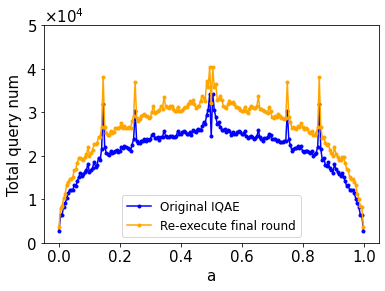

In [17]:
plt.rcParams["font.size"] = 15

aveQueryNum = [np.mean(t) for t in totQueryNums]
aveQueryNum_FinalRedo = [np.mean(t) for t in totQueryNums_FinalRedo]

ax = plt.gca()
plt.plot(ps, aveQueryNum, label="Original IQAE", marker=".", color="blue")
plt.plot(ps, aveQueryNum_FinalRedo, label="Re-execute final round", marker=".",color="orange")
plt.legend()
ax.set_ylim(0,50000)
ax.set_xlabel("a")
ax.set_ylabel("Total query num")
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(4,4)) 
plt.legend(fontsize=12)
plt.show()

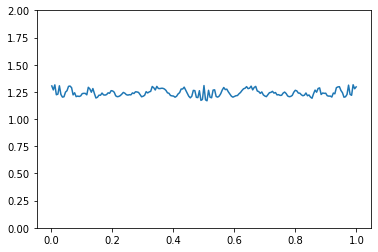

In [13]:
ax = plt.gca()
plt.plot(ps, np.array(aveQueryNum_FinalRedo) / np.array(aveQueryNum))
ax.set_ylim(0,2)
plt.show()

クエリ回数のグラフのピークは何？

In [17]:
queryNumDf = pd.DataFrame({"p":ps, "aveQueryNum":aveQueryNum})
queryNumDf.sort_values("aveQueryNum", ascending=False)[:10]

,p,aveQueryNum
101,0.50499,34254.1194
99,0.49501,34219.6580
171,0.85429,31998.0336
29,0.14571,31977.8145
102,0.50998,30572.3495
98,0.49002,30549.3329
150,0.74950,30286.8488
50,0.25050,30240.3722
97,0.48503,29437.2196
103,0.51497,28872.7772


In [6]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.14570999999999998_epsilon0001_alpha005.dat", 'rb') as f:
    res_p014571 = pickle.load(f)

In [7]:
res_p014571

array([{'Estimate': 0.14537445904468865, 'TotalOracleCalls': 30525, 'nGrover': [0, 2, 5, 12, 25, 52, 105, 215], 'nShots': [719, 195, 155, 114, 138, 61, 35, 8], 'n1s': [131, 168, 136, 14, 118, 5, 21, 6], 'thetaIntervals': [[0, 1.5707963267948966], [0.314502312870697, 0.5449373337271426], [0.3141592653589793, 0.4282559988292055], [0.37701977719941326, 0.42839899821678995], [0.37699111843077515, 0.4003804711963566], [0.3889860809014708, 0.4003990636928168], [0.3889590904444506, 0.3945384841293835], [0.38997558412349403, 0.3928689582486209], [0.38996567741775856, 0.39251048075100503]], 'ampSqIntervals': [[0, 1], [0.09569323627133697, 0.26870175677456004], [0.09549150281252627, 0.17246157469366324], [0.13553530516513432, 0.17256963302735742], [0.1355156862892942, 0.1519196794842917], [0.1438308938894082, 0.1519330270185367], [0.14381195152432757, 0.14774965282832822], [0.1445260602342202, 0.14656675067052896], [0.1445190934656604, 0.14631327355283072]]},
       {'Estimate': 0.14576830110202

In [8]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.13573_epsilon0001_alpha005.dat", 'rb') as f:
    res_p013573 = pickle.load(f)

In [9]:
res_p013573

array([{'Estimate': 0.1356850669647063, 'TotalOracleCalls': 18700, 'nGrover': [0, 1, 3, 7, 15, 32, 71, 151, 317], 'nShots': [345, 234, 83, 76, 38, 49, 36, 17, 2], 'n1s': [43, 188, 23, 21, 24, 14, 5, 16, 1], 'thetaIntervals': [[0, 1.5707963267948966], [0.0, 0.5230414977288458], [0.315994286882395, 0.44624174665350225], [0.33552158117818326, 0.41769067543434285], [0.36608694076045106, 0.40444501149019535], [0.3625373176158548, 0.38593342292475835], [0.37388196271392243, 0.3841431798491169], [0.37347604972745796, 0.37842529324070434], [0.37603549236109085, 0.37844267939282983], [0.3760016404296445, 0.3784753354324711]], 'ampSqIntervals': [[0, 1], [0.0, 0.2495175385873031], [0.09657282318341456, 0.1862598824750502], [0.10841327483984113, 0.16455253010309145], [0.12813852642350873, 0.15484902492103267], [0.12577503669296708, 0.1416950789074108], [0.13339438326493244, 0.14044872983362108], [0.13311848288809802, 0.13649894454207753], [0.13486218133660147, 0.1365108827062898], [0.1348390561380

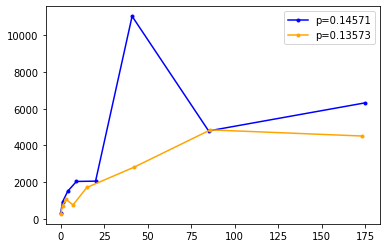

In [10]:
trialExample_p014571 = res_p014571[1]
queryNumEachRound_p014571 = (2 * np.array(trialExample_p014571["nGrover"]) + 1) * np.array(trialExample_p014571["nShots"])

trialExample_p013573 = res_p013573[1]
queryNumEachRound_p013573 = (2 * np.array(trialExample_p013573["nGrover"]) + 1) * np.array(trialExample_p013573["nShots"])

ax = plt.gca()
plt.plot(trialExample_p014571["nGrover"], queryNumEachRound_p014571, label="p=0.14571", marker=".", color="blue")
plt.plot(trialExample_p013573["nGrover"], queryNumEachRound_p013573, label="p=0.13573", marker=".",color="orange")
plt.legend()
plt.show()

In [11]:
print(trialExample_p014571["nGrover"])
print(trialExample_p014571["nShots"])

[0, 1, 4, 9, 20, 41, 85, 175]
[339, 306, 167, 107, 50, 133, 28, 18]


nGrover=41で何が起こってる？

In [17]:
# sin^2(Kθ)の分布
p014571 = 0.14571
theta_p014571 = np.arcsin(np.sqrt(p014571))

sinKTheta_p014571 =[]
for r in res_p014571:
    sinKTheta_p014571.append(np.sin((2 * np.array(r["nGrover"]) + 1) * theta_p014571) ** 2)

p013573 = 0.13573
theta_p013573 = np.arcsin(np.sqrt(p013573))

sinKTheta_p013573 =[]
for r in res_p013573:
    sinKTheta_p013573.append(np.sin((2 * np.array(r["nGrover"]) + 1) * theta_p013573) ** 2)

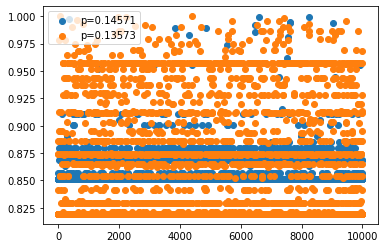

In [20]:
nSamp = len(res_p014571)
ax = plt.gca()
plt.scatter(np.arange(nSamp), [np.max(probs) for probs in sinKTheta_p014571], label="p=0.14571")
plt.scatter(np.arange(nSamp), [np.max(probs) for probs in sinKTheta_p013573], label="p=0.13573")
plt.legend()
plt.show()

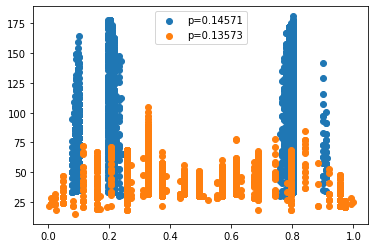

In [23]:
nSamp = len(res_p014571)
ax = plt.gca()
plt.scatter([probs[5] for probs in sinKTheta_p014571], [r["nShots"][5] for r in res_p014571], label="p=0.14571")
plt.scatter([probs[5] for probs in sinKTheta_p013573], [r["nShots"][5] for r in res_p013573], label="p=0.13573")
plt.legend()
plt.show()